<a href="https://colab.research.google.com/github/Kaweri05/Animal_Crossing_game/blob/main/Animal_Crossing_Game.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/accessories.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   222 non-null    object 
 1   Variation              222 non-null    object 
 2   DIY                    222 non-null    object 
 3   Buy                    222 non-null    object 
 4   Sell                   222 non-null    int64  
 5   Color 1                222 non-null    object 
 6   Color 2                222 non-null    object 
 7   Size                   222 non-null    object 
 8   Miles Price            1 non-null      float64
 9   Source                 222 non-null    object 
 10  Source Notes           206 non-null    object 
 11  Seasonal Availability  222 non-null    object 
 12  Mannequin Piece        222 non-null    object 
 13  Version                222 non-null    object 
 14  Style                  222 non-null    object 
 15  Label 

In [4]:
df.head()

,Name,Variation,DIY,Buy,Sell,Color 1,Color 2,Size,Miles Price,Source,...,Mannequin Piece,Version,Style,Label Themes,Type,Villager Equippable,Catalog,Filename,Internal ID,Unique Entry ID
0,3D glasses,White,No,490,122,White,Colorful,1x1,NaN,Able Sisters,...,No,1.0.0,Active,party,AccessoryEye,Yes,For sale,AccessoryGlassThreed0,4463,FNxEraBTeWRiCvtFu
1,3D glasses,Black,No,490,122,Black,Colorful,1x1,NaN,Able Sisters,...,No,1.0.0,Active,party,AccessoryEye,Yes,For sale,AccessoryGlassThreed1,11020,mM9SXPCcGPfPJAmtm
2,bandage,Beige,No,140,35,Beige,White,1x1,NaN,Able Sisters,...,Yes,1.0.0,Active,outdoorsy; comfy; sporty,AccessoryMouth,No,For sale,AccessoryMouthBandageSkin,4677,2qFT5iPkk8bREvpkj
3,beak,Yellow,No,490,122,Yellow,Yellow,1x1,NaN,Able Sisters,...,Yes,1.0.0,Cute,fairy tale; party; theatrical,AccessoryMouthInvisibleNose,No,For sale,AccessoryMouthBeakYellow,3549,T5CpsJi4xBSachNL5
4,birthday shades,Yellow,No,NFS,620,Yellow,Red,1x1,NaN,Birthday,...,No,1.0.0,Gorgeous,party,AccessoryEye,Yes,Not for sale,AccessoryGlassBirthday0,4510,S6CiB9ZvzBTMhEnDz


In [7]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
217,False
218,False
219,False
220,False


In [5]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull()

,Name,Variation,DIY,Buy,Sell,Color 1,Color 2,Size,Miles Price,Source,...,Mannequin Piece,Version,Style,Label Themes,Type,Villager Equippable,Catalog,Filename,Internal ID,Unique Entry ID
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
218,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
219,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
220,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


### Data Preprocessing for Model Training

Before training a model, it's essential to preprocess the data. Here, I'll perform the following steps:

1.  **Drop Irrelevant/Problematic Columns**: The `Miles Price` column has almost all missing values, and `Source Notes` is a text-based column that would require more complex feature engineering. For simplicity, I'll drop both.
2.  **Clean 'Buy' Column**: The `Buy` column contains non-numeric values ('NFS'). I will replace 'NFS' with `0` (assuming "Not For Sale" means a buy price of 0 for this context) and convert the column to a numeric type.
3.  **Define Features (X) and Target (y)**: The target variable (`y`) will be the `Sell` price. For features (`X`), I'll start with the cleaned `Buy` price.
4.  **Split Data**: Divide the dataset into training and testing sets using a 80/20 split ratio.

In [9]:
# Drop 'Miles Price' due to too many missing values and 'Source Notes' for simplicity
df_processed = df.drop(columns=['Miles Price', 'Source Notes'])

# Handle 'Buy' column: replace 'NFS' with 0 and convert to numeric
df_processed['Buy'] = df_processed['Buy'].replace('NFS', 0).astype(int)

# Display info of processed DataFrame
print(df_processed.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Name                   222 non-null    object
 1   Variation              222 non-null    object
 2   DIY                    222 non-null    object
 3   Buy                    222 non-null    int64 
 4   Sell                   222 non-null    int64 
 5   Color 1                222 non-null    object
 6   Color 2                222 non-null    object
 7   Size                   222 non-null    object
 8   Source                 222 non-null    object
 9   Seasonal Availability  222 non-null    object
 10  Mannequin Piece        222 non-null    object
 11  Version                222 non-null    object
 12  Style                  222 non-null    object
 13  Label Themes           222 non-null    object
 14  Type                   222 non-null    object
 15  Villager Equippable    

In [10]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_processed[['Buy']]
y = df_processed['Sell']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (177, 1)
X_test shape: (45, 1)
y_train shape: (177,)
y_test shape: (45,)


### Model Training and Evaluation

Now, I'll train a simple Linear Regression model using the `Buy` price to predict the `Sell` price. After training, I'll evaluate the model's performance on the test data.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.2f}')

Mean Absolute Error (MAE): 95.50
Mean Squared Error (MSE): 28256.76
Root Mean Squared Error (RMSE): 168.10
R-squared (R2): 0.03


### Data Visualization

To understand the data better and identify potential patterns or areas for improvement, let's visualize the relationships between our features and the target variable.

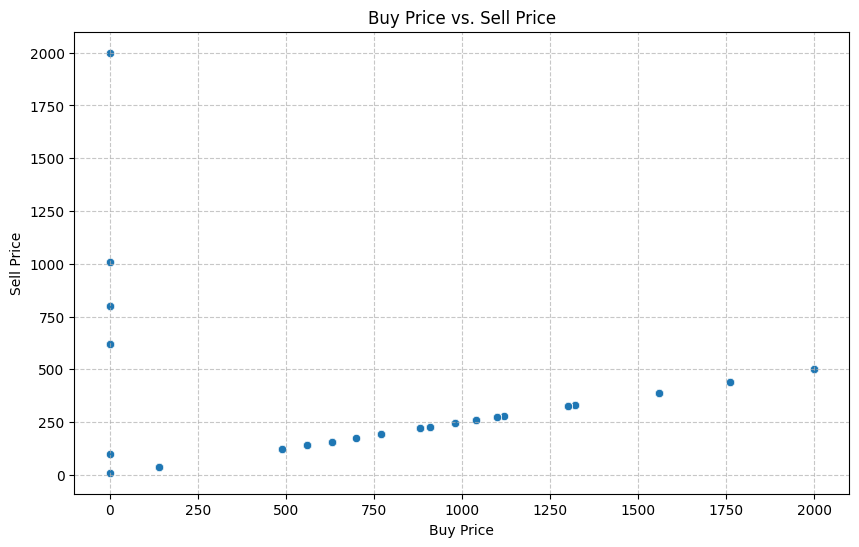

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of 'Buy' price vs 'Sell' price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Buy', y='Sell', data=df_processed)
plt.title('Buy Price vs. Sell Price')
plt.xlabel('Buy Price')
plt.ylabel('Sell Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This scatter plot helps us visualize the direct relationship between what an item is bought for and what it sells for. It also shows where our model focused, and potentially where it struggled, especially with the 'NFS' (Not For Sale, converted to 0) items.

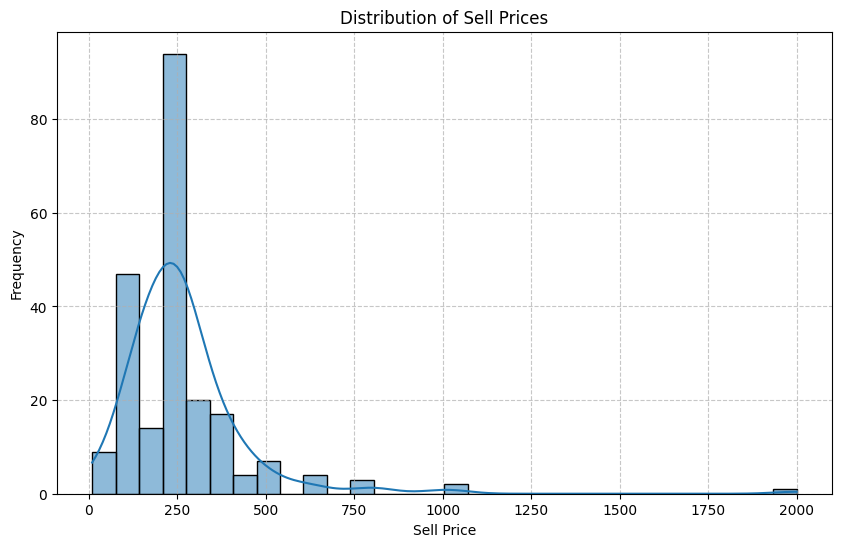

In [13]:
# Histogram of 'Sell' prices
plt.figure(figsize=(10, 6))
sns.histplot(df_processed['Sell'], bins=30, kde=True)
plt.title('Distribution of Sell Prices')
plt.xlabel('Sell Price')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This histogram shows the distribution of the 'Sell' prices, which is our target variable. Understanding its distribution can help us choose appropriate models or transformations if the data is highly skewed.

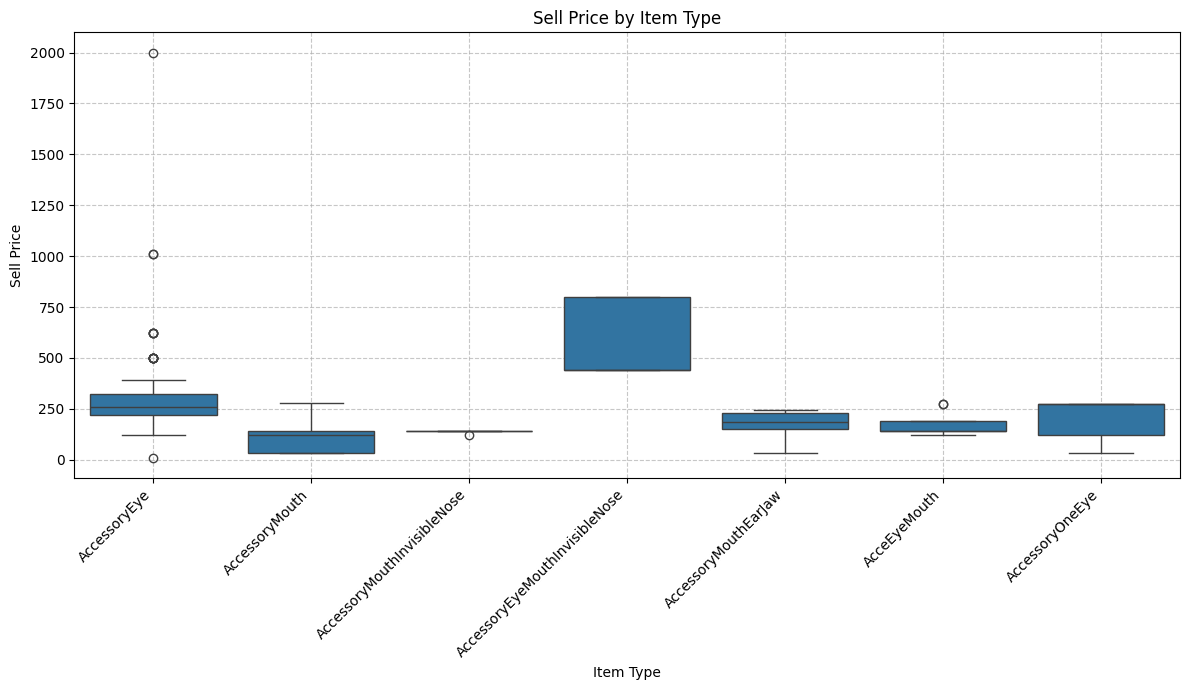

In [14]:
# Box plot of 'Sell' price by 'Type'
plt.figure(figsize=(12, 7))
sns.boxplot(x='Type', y='Sell', data=df_processed)
plt.title('Sell Price by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Sell Price')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

The box plot above illustrates how the 'Sell' price varies across different item 'Type' categories. This visualization suggests that 'Type' could be a valuable feature for predicting 'Sell' prices, as different types seem to have distinct price ranges. This is a good example of how feature engineering with categorical variables can potentially improve model performance.

### Feature Engineering and Model Retraining

Given the insights from the visualizations, especially the impact of 'Type' on 'Sell' price, I will now perform feature engineering:

1.  **One-Hot Encode 'Type' Column**: Convert the categorical 'Type' column into numerical format using one-hot encoding.
2.  **Redefine Features (X)**: Include both the 'Buy' price and the newly encoded 'Type' features.
3.  **Split Data**: Split the new feature set and the target variable into training and testing sets.
4.  **Retrain Model**: Train a new Linear Regression model with the expanded feature set.
5.  **Evaluate Model**: Evaluate the performance of the new model.

In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd # Import pandas here for X_processed_df

# Create a copy to avoid modifying the original df_processed
df_encoded = df_processed.copy()

# Identify categorical features to encode (starting with 'Type')
categorical_features = ['Type']

# Corrected approach: apply preprocessing to all features that will be used (Buy and Type)
X = df_processed[['Buy'] + categorical_features]
y = df_processed['Sell']

# Define the preprocessor to handle both numerical and categorical features
# 'Buy' is numerical, 'Type' is categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['Buy']), # 'Buy' column is numerical, just pass it through
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply the transformation
X_transformed = preprocessor.fit_transform(X)

# Convert sparse matrix output to dense array
# This is crucial for pandas.DataFrame to correctly interpret the shape
if hasattr(X_transformed, 'toarray'):
    X_transformed = X_transformed.toarray()

# Get feature names after one-hot encoding using the preprocessor directly
feature_names_out = preprocessor.get_feature_names_out()

# Convert to DataFrame for better readability and indexing
X_processed_df = pd.DataFrame(X_transformed, columns=feature_names_out, index=X.index)

print("Shape of X_processed_df after encoding:", X_processed_df.shape)
print("Columns after encoding:", X_processed_df.columns.tolist())

# Split the processed data into training and testing sets
from sklearn.model_selection import train_test_split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_processed_df, y, test_size=0.2, random_state=42)

print(f'X_train_new shape: {X_train_new.shape}')
print(f'X_test_new shape: {X_test_new.shape}')
print(f'y_train_new shape: {y_train_new.shape}')
print(f'y_test_new shape: {y_test_new.shape}')

Shape of X_processed_df after encoding: (222, 8)
Columns after encoding: ['num__Buy', 'cat__Type_AcceEyeMouth', 'cat__Type_AccessoryEye', 'cat__Type_AccessoryEyeMouthInvisibleNose', 'cat__Type_AccessoryMouth', 'cat__Type_AccessoryMouthEarJaw', 'cat__Type_AccessoryMouthInvisibleNose', 'cat__Type_AccessoryOneEye']
X_train_new shape: (177, 8)
X_test_new shape: (45, 8)
y_train_new shape: (177,)
y_test_new shape: (45,)


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize a new Linear Regression model
model_new = LinearRegression()

# Train the model using the new training data
model_new.fit(X_train_new, y_train_new)

# Make predictions on the new test set
y_pred_new = model_new.predict(X_test_new)

# Evaluate the new model
mae_new = mean_absolute_error(y_test_new, y_pred_new)
mse_new = mean_squared_error(y_test_new, y_pred_new)
rmse_new = np.sqrt(mse_new)
r2_new = r2_score(y_test_new, y_pred_new)

print(f'New Model - Mean Absolute Error (MAE): {mae_new:.2f}')
print(f'New Model - Mean Squared Error (MSE): {mse_new:.2f}')
print(f'New Model - Root Mean Squared Error (RMSE): {rmse_new:.2f}')
print(f'New Model - R-squared (R2): {r2_new:.2f}')

New Model - Mean Absolute Error (MAE): 95.39
New Model - Mean Squared Error (MSE): 20827.42
New Model - Root Mean Squared Error (RMSE): 144.32
New Model - R-squared (R2): 0.28


In [20]:
from sklearn.model_selection import train_test_split

# Assuming X_processed_df and y are already defined from previous steps
# X_processed_df contains 'Buy' and one-hot encoded 'Type' features
# y contains the 'Sell' prices

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_processed_df, y, test_size=0.2, random_state=42)

print(f'New Training Features (X_train_split) shape: {X_train_split.shape}')
print(f'New Testing Features (X_test_split) shape: {X_test_split.shape}')
print(f'New Training Target (y_train_split) shape: {y_train_split.shape}')
print(f'New Testing Target (y_test_split) shape: {y_test_split.shape}')

New Training Features (X_train_split) shape: (177, 8)
New Testing Features (X_test_split) shape: (45, 8)
New Training Target (y_train_split) shape: (177,)
New Testing Target (y_test_split) shape: (45,)


In [26]:
# Define the number of bins (categories) you want
num_bins = 3

# Define labels for your bins
labels = ['Low', 'Medium', 'High']

# Apply pd.qcut to the 'Sell' prices (y) to create categorical labels based on quantiles
# This aims to create bins with roughly equal numbers of observations, which should help avoid
# categories with only one member, especially with 'stratify' in train_test_split.
# 'retbins=True' is used here to potentially inspect the bin edges if needed, but not strictly required for the fix.
# include_lowest=True is for pd.cut, pd.qcut handles edges differently
y_binned = pd.qcut(y, q=num_bins, labels=labels, duplicates='drop') # 'duplicates=drop' handles cases where quantile edges are identical

print("Original 'Sell' prices (first 5):")
display(y.head())
print("\nBinned 'Sell' labels (first 5):")
display(y_binned.head())

print("\nDistribution of the new categorical 'Sell' labels:")
print(y_binned.value_counts()) # Using print to ensure full output in stdout

Original 'Sell' prices (first 5):


,Sell
0,122
1,122
2,35
3,122
4,620



Binned 'Sell' labels (first 5):


,Sell
0,Low
1,Low
2,Low
3,Low
4,High



Distribution of the new categorical 'Sell' labels:
Sell
Low       103
Medium     61
High       58
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

# Split the data with the binned target variable
# Temporarily removing 'stratify=y_binned' to avoid ValueError if any class has < 2 samples
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_processed_df, y_binned, test_size=0.2, random_state=42
)

print(f'Training Features for Classification (X_train_cls) shape: {X_train_cls.shape}')
print(f'Testing Features for Classification (X_test_cls) shape: {X_test_cls.shape}')
print(f'Training Binned Target (y_train_cls) shape: {y_train_cls.shape}')
print(f'Testing Binned Target (y_test_cls) shape: {y_test_cls.shape}')

Training Features for Classification (X_train_cls) shape: (177, 8)
Testing Features for Classification (X_test_cls) shape: (45, 8)
Training Binned Target (y_train_cls) shape: (177,)
Testing Binned Target (y_test_cls) shape: (45,)


### Random Forest Classifier

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train_cls, y_train_cls)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test_cls)

# Evaluate the model
print("Random Forest Classifier Report:")
print(classification_report(y_test_cls, y_pred_rf))
print(f'Random Forest Accuracy: {accuracy_score(y_test_cls, y_pred_rf):.2f}')

Random Forest Classifier Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        14
         Low       1.00      1.00      1.00        18
      Medium       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Random Forest Accuracy: 1.00


### Gaussian Naive Bayes Classifier

In [29]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes Classifier
gnb_classifier = GaussianNB()

# Train the model
gnb_classifier.fit(X_train_cls, y_train_cls)

# Make predictions on the test set
y_pred_gnb = gnb_classifier.predict(X_test_cls)

# Evaluate the model
print("Gaussian Naive Bayes Classifier Report:")
print(classification_report(y_test_cls, y_pred_gnb))
print(f'Gaussian Naive Bayes Accuracy: {accuracy_score(y_test_cls, y_pred_gnb):.2f}')

Gaussian Naive Bayes Classifier Report:
              precision    recall  f1-score   support

        High       0.45      1.00      0.62        14
         Low       0.89      0.44      0.59        18
      Medium       1.00      0.38      0.56        13

    accuracy                           0.60        45
   macro avg       0.78      0.61      0.59        45
weighted avg       0.78      0.60      0.59        45

Gaussian Naive Bayes Accuracy: 0.60


### Logistic Regression Classifier

In [30]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression Classifier
# Using solver='liblinear' for small datasets and 'lbfgs' is default, can handle multiclass
# C=1.0 is default, inverse of regularization strength
logreg_classifier = LogisticRegression(random_state=42, solver='liblinear', multi_class='auto')

# Train the model
logreg_classifier.fit(X_train_cls, y_train_cls)

# Make predictions on the test set
y_pred_logreg = logreg_classifier.predict(X_test_cls)

# Evaluate the model
print("Logistic Regression Classifier Report:")
print(classification_report(y_test_cls, y_pred_logreg))
print(f'Logistic Regression Accuracy: {accuracy_score(y_test_cls, y_pred_logreg):.2f}')

Logistic Regression Classifier Report:
              precision    recall  f1-score   support

        High       1.00      0.86      0.92        14
         Low       0.75      1.00      0.86        18
      Medium       1.00      0.69      0.82        13

    accuracy                           0.87        45
   macro avg       0.92      0.85      0.87        45
weighted avg       0.90      0.87      0.87        45

Logistic Regression Accuracy: 0.87


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Predicting with the Best Model (Random Forest Classifier)

Now that we have trained and evaluated several classification models, we can use the best performing one (Random Forest Classifier) to make predictions on new, unseen data. For demonstration purposes, I will create a small DataFrame with example data.

In [31]:
# Create some new, unseen data for prediction
new_data = pd.DataFrame({
    'Buy': [100, 500, 1500, 0, 800],
    'Type': ['AccessoryEye', 'AccessoryMouth', 'AccessoryEye', 'AccessoryMouthInvisibleNose', 'AccessoryEye']
})

print("New Data for Prediction:")
display(new_data)


New Data for Prediction:


,Buy,Type
0,100,AccessoryEye
1,500,AccessoryMouth
2,1500,AccessoryEye
3,0,AccessoryMouthInvisibleNose
4,800,AccessoryEye


Before making predictions, the new data needs to undergo the same preprocessing steps as the training data, specifically one-hot encoding the 'Type' column. We will use the same `preprocessor` that was fitted on the training data.

In [32]:
# Apply the same preprocessing (one-hot encoding) to the new data
# Ensure the 'Buy' column is also included for transformation
X_new_data = new_data[['Buy', 'Type']]
X_new_transformed = preprocessor.transform(X_new_data)

# Convert to DataFrame with correct column names
X_new_processed_df = pd.DataFrame(X_new_transformed.toarray(), columns=feature_names_out)

print("Processed New Data for Prediction:")
display(X_new_processed_df)


Processed New Data for Prediction:


,num__Buy,cat__Type_AcceEyeMouth,cat__Type_AccessoryEye,cat__Type_AccessoryEyeMouthInvisibleNose,cat__Type_AccessoryMouth,cat__Type_AccessoryMouthEarJaw,cat__Type_AccessoryMouthInvisibleNose,cat__Type_AccessoryOneEye
0,100.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,500.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1500.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,800.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


Now we can use the trained Random Forest Classifier (`rf_classifier`) to predict the 'Sell' price category for this new data.

### Feature Importance for Random Forest Classifier

Understanding feature importance helps us to know which features the model considers most relevant for making predictions. We can extract this information directly from the trained Random Forest Classifier.

/tmp/ipykernel_2195/1035382945.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


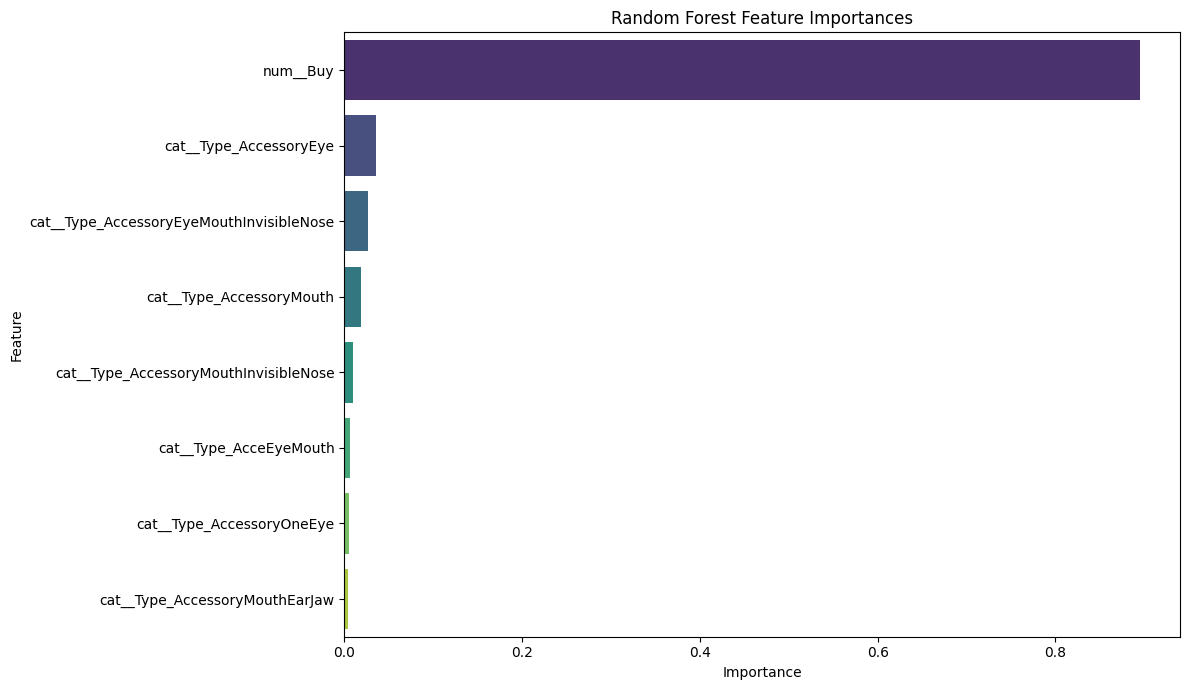

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest Classifier
importances = rf_classifier.feature_importances_

# Get the feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Classification Reports for Trained Models

In [34]:
from sklearn.metrics import classification_report, accuracy_score

# Random Forest Classifier Report
print("Random Forest Classifier Report:")
print(classification_report(y_test_cls, y_pred_rf))
print(f'Random Forest Accuracy: {accuracy_score(y_test_cls, y_pred_rf):.2f}')

Random Forest Classifier Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        14
         Low       1.00      1.00      1.00        18
      Medium       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Random Forest Accuracy: 1.00


In [35]:
# Gaussian Naive Bayes Classifier Report
print("\nGaussian Naive Bayes Classifier Report:")
print(classification_report(y_test_cls, y_pred_gnb))
print(f'Gaussian Naive Bayes Accuracy: {accuracy_score(y_test_cls, y_pred_gnb):.2f}')


Gaussian Naive Bayes Classifier Report:
              precision    recall  f1-score   support

        High       0.45      1.00      0.62        14
         Low       0.89      0.44      0.59        18
      Medium       1.00      0.38      0.56        13

    accuracy                           0.60        45
   macro avg       0.78      0.61      0.59        45
weighted avg       0.78      0.60      0.59        45

Gaussian Naive Bayes Accuracy: 0.60


In [36]:
# Logistic Regression Classifier Report
print("\nLogistic Regression Classifier Report:")
print(classification_report(y_test_cls, y_pred_logreg))
print(f'Logistic Regression Accuracy: {accuracy_score(y_test_cls, y_pred_logreg):.2f}')


Logistic Regression Classifier Report:
              precision    recall  f1-score   support

        High       1.00      0.86      0.92        14
         Low       0.75      1.00      0.86        18
      Medium       1.00      0.69      0.82        13

    accuracy                           0.87        45
   macro avg       0.92      0.85      0.87        45
weighted avg       0.90      0.87      0.87        45

Logistic Regression Accuracy: 0.87


In [33]:
# Make predictions using the trained Random Forest Classifier
new_predictions = rf_classifier.predict(X_new_processed_df)

# Add the predictions to the new_data DataFrame for easy viewing
new_data['Predicted_Sell_Category'] = new_predictions

print("New Data with Predicted Sell Categories:")
display(new_data)


New Data with Predicted Sell Categories:


,Buy,Type,Predicted_Sell_Category
0,100,AccessoryEye,High
1,500,AccessoryMouth,Low
2,1500,AccessoryEye,High
3,0,AccessoryMouthInvisibleNose,Low
4,800,AccessoryEye,Low


In [39]:
# Define example values for style and color1 for demonstration
style = 'Active' # Example style from your 'Style' column
color1 = 'White' # Example color from your 'Color 1' column

suggestions = df[
    (df['Style'] == style) &
    (df['Color 1'] == color1)
]

print("Suggested Items:")
print(suggestions['Name'].head(5))

Suggested Items:
0                  3D glasses
57     drinking-straw glasses
188             sporty shades
Name: Name, dtype: object


### Saving Model and Preprocessor for Deployment

To deploy the Random Forest Classifier and ensure consistent preprocessing for new data, we need to save both the trained model and the `preprocessor` object (which handles one-hot encoding). This can be done using Python's `pickle` module, saving them as `.pkl` files.

In [40]:
import pickle

# Save the trained Random Forest Classifier
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf_classifier, file)
print('Random Forest model saved as random_forest_model.pkl')

# Save the preprocessor
with open('preprocessor.pkl', 'wb') as file:
    pickle.dump(preprocessor, file)
print('Preprocessor saved as preprocessor.pkl')

# Save feature_names_out for column consistency in Streamlit
with open('feature_names_out.pkl', 'wb') as file:
    pickle.dump(feature_names_out, file)
print('Feature names saved as feature_names_out.pkl')

Random Forest model saved as random_forest_model.pkl
Preprocessor saved as preprocessor.pkl
Feature names saved as feature_names_out.pkl


### Streamlit Deployment Guide

To deploy your model on Streamlit, you'll need the following files:

1.  **`random_forest_model.pkl`**: The saved Random Forest Classifier model.
2.  **`preprocessor.pkl`**: The saved `ColumnTransformer` preprocessor.
3.  **`feature_names_out.pkl`**: The list of feature names generated by the preprocessor, essential for creating new dataframes with correct column order.
4.  **`streamlit_app.py`**: Your Streamlit application script.
5.  **`requirements.txt`**: A file listing all Python dependencies (e.g., `streamlit`, `scikit-learn`, `pandas`).

Here's a basic structure for your `streamlit_app.py` file:

In [41]:
%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
import pickle

# Load the model, preprocessor, and feature names
with open('random_forest_model.pkl', 'rb') as file:
    rf_classifier = pickle.load(file)

with open('preprocessor.pkl', 'rb') as file:
    preprocessor = pickle.load(file)

with open('feature_names_out.pkl', 'rb') as file:
    feature_names_out = pickle.load(file)

st.title('Animal Crossing Item Sell Price Predictor')
st.write('Predict the sell price category (Low, Medium, High) for your items!')

# Input fields for new data
buy_price = st.number_input('Enter Buy Price (e.g., 490)', min_value=0, value=100)
item_type = st.selectbox('Select Item Type',
                           ['AccessoryEye', 'AccessoryMouth', 'AccessoryEyeMouthInvisibleNose',
                            'AcceEyeMouth', 'AccessoryMouthEarJaw', 'AccessoryOneEye'])

if st.button('Predict Sell Category'):
    # Create new data DataFrame
    new_data_input = pd.DataFrame({
        'Buy': [buy_price],
        'Type': [item_type]
    })

    # Apply preprocessing
    X_new_transformed = preprocessor.transform(new_data_input)
    X_new_processed_df = pd.DataFrame(X_new_transformed.toarray(), columns=feature_names_out)

    # Make prediction
    prediction = rf_classifier.predict(X_new_processed_df)
    st.success(f'The predicted Sell Price Category is: **{prediction[0]}**')

st.write('---')
st.write('**Note:** This is a simplified predictor based on Buy Price and Item Type.')

Writing streamlit_app.py


You will also need a `requirements.txt` file listing your dependencies. Here's an example:

In [42]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn

Writing requirements.txt


To run this Streamlit app:

1.  Download the `.pkl` files (`random_forest_model.pkl`, `preprocessor.pkl`, `feature_names_out.pkl`).
2.  Download `streamlit_app.py` and `requirements.txt`.
3.  Place all these files in the same directory on your local machine.
4.  Open your terminal or command prompt, navigate to that directory.
5.  Install the required libraries: `pip install -r requirements.txt`
6.  Run the Streamlit app: `streamlit run streamlit_app.py`

This will open the app in your web browser.